# Band gaps from the Tran-Blaha potential

A semilocal functional underestimates the band gap, and it does so by about a factor of two.
Silicon's is 1.17 eV; LDA gives 0.5. The usual fixes, a hybrid functional or $GW$, cost one
or two orders of magnitude more than the self-consistent run they correct.

**Tran and Blaha's modified Becke-Johnson potential** ([Phys. Rev. Lett. **102**, 226401
(2009)](https://doi.org/10.1103/PhysRevLett.102.226401)) gets most of the gap back for the
price of a gradient-corrected functional. It is written down as a *potential*:

$$v_{x,\sigma}^{\mathrm{mBJ}}(\mathbf r) = c\,v_{x,\sigma}^{\mathrm{BR}}(\mathbf r)
  + (3c-2)\,\frac{1}{\pi}\sqrt{\frac{5}{12}}\,
    \sqrt{\frac{2\tau_\sigma(\mathbf r)}{\rho_\sigma(\mathbf r)}},
\qquad
c = \alpha + \beta\left[\frac{1}{V_{\rm cell}}\int_{\rm cell}
     \frac{|\nabla\rho|}{\rho}\,\mathrm d^3r'\right]^{1/2}$$

with $\alpha = -0.012$, $\beta = 1.023\,a_0^{1/2}$, and $v_x^{\rm BR}$ the Becke-Roussel
model of the exchange hole. $c = 1$ recovers Becke-Johnson.

| silicon, indirect gap | |
|---|---|
| LDA | **0.49 eV** |
| TB09 | **1.13 eV** |
| experiment | 1.17 eV |
| published all-electron mBJ | 1.17 eV |

Two things follow from it being a potential rather than the derivative of an energy. The
total energy is **not variational**, so forces, stress, phonons and linear response are
refused by name and the eigenvalues are the point. And the coefficient $c$ is an average
over the whole cell, so the potential at one point depends on the density everywhere, which
is unlike every other functional here. The run also carries a second field, the kinetic
energy density $\tau$, which comes from the states rather than from the density.

`pw.x` cannot compute this. It reaches TB09 only through libxc, and then passes a zero
Laplacian and never sets $c$, so what it runs under that name is Becke-Johnson.

In [1]:
import warnings
from pathlib import Path

from defumat import Calculator

# The TB09 runs emit two warnings, both quoted just below; silenced by name here
# so that what this notebook prints is its numbers.
warnings.filterwarnings("ignore", message="input_dft asks for TB09")
warnings.filterwarnings("ignore", message="TB09 is a potential")

CASES, PSEUDO = Path("../tests/data/qe"), Path("../tests/data/pseudo")
runs = {label: Calculator.from_file(CASES / f"si2-{stem}.in", pseudo_dir=PSEUDO,
        announce=False) for label, stem in (("LDA", "lda-gap"), ("TB09", "tb09"))}

scf = runs["TB09"].get_scf()
print("silicon, TB09:   c = %.4f after %d iterations" % (scf.meta_c, scf.iterations))

silicon, TB09:   c = 1.0331 after 10 iterations


The two inputs differ by `input_dft = 'tb09'` and by nothing else.

The TB09 run emits two warnings, silenced by name above only to keep the output short. The first
is that this pseudopotential was generated with PZ, which `pw.x` says too and which every
published mBJ pseudopotential calculation lives with, there being no such thing as an
mBJ-generated dataset. The second is the package refusing in advance: the total energy this
run reports is not the value of anything that was minimised, so forces, stress and response
are refused for it, and it is not comparable with a total energy from any other functional.

$c$ is not a parameter of the functional but an output of the run, measured from the density
it converged to, and it has to converge along with everything else. On this cell it settles
at about 1.03.

## The same bands, twice

The valence bands are almost untouched, because the potential corrects *exchange* and the
occupied manifold is what the density constrains. The conduction bands move up nearly
rigidly, which is the mechanism in one picture: mBJ acts like a scissor operator whose size
the density itself sets, rather than one applied by hand.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from defumat.system.kpoints import KPoints
from defumat.units import RY_TO_EV

FCC = {"L": (.5, .5, .5), "G": (0., 0., 0.), "X": (0., 0., 1.),
       "W": (.5, 0., 1.), "K": (.75, .75, 0.)}
PATH, COUNTS, NOCC = ["L", "G", "X", "W", "K", "G"], [25, 25, 25, 25, 25, 1], 4
kpath = KPoints.band_path([FCC[p] for p in PATH], COUNTS,
                          runs["LDA"].system.cell, crystal=False)

bands, gaps = {}, {}
for label, calc in runs.items():
    levels = np.asarray(calc.get_bands(kpoints=kpath).eigenvalues) * RY_TO_EV
    bands[label] = levels - levels[:, :NOCC].max()
    gaps[label] = (bands[label][:, NOCC:].min(),
                   (bands[label][:, NOCC:].min(axis=1)
                    - bands[label][:, :NOCC].max(axis=1)).min())

print("%-10s %14s %12s" % ("", "indirect [eV]", "direct [eV]"))
for label in runs:
    print("%-10s %14.3f %12.3f" % (label, gaps[label][0], gaps[label][1]))
print("%-10s %14.3f %12.3f" % ("experiment", 1.17, 3.40))

            indirect [eV]  direct [eV]
LDA                 0.493        2.567
TB09                1.133        3.168
experiment          1.170        3.400


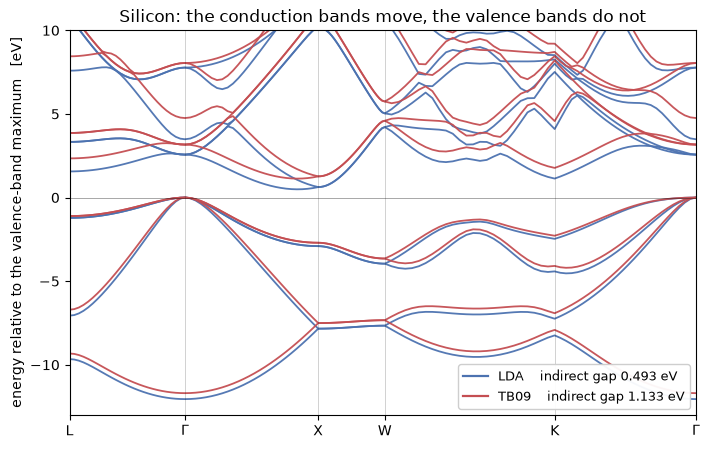

In [3]:
x = np.asarray(kpath.path_length)
edges = x[np.cumsum([0] + COUNTS[:-1])]

fig, ax = plt.subplots(figsize=(7.2, 4.6))
for label, colour in (("LDA", "#4c72b0"), ("TB09", "#c44e52")):
    ax.plot(x, bands[label], color=colour, lw=1.3, alpha=0.95)
    ax.plot([], [], color=colour, lw=1.6,
            label="%s    indirect gap %.3f eV" % (label, gaps[label][0]))
ax.axhline(0.0, color="k", lw=0.6, alpha=0.4)
for edge in edges[1:-1]:
    ax.axvline(edge, color="k", lw=0.5, alpha=0.25)
ax.set_xticks(edges)
ax.set_xticklabels([p if p != "G" else r"$\Gamma$" for p in PATH])
ax.set_xlim(x[0], x[-1])
ax.set_ylim(-13, 10)
ax.set_ylabel("energy relative to the valence-band maximum   [eV]")
ax.set_title("Silicon: the conduction bands move, the valence bands do not")
ax.legend(loc="lower right", fontsize=9, framealpha=0.95)
fig.tight_layout()

## Where the remaining shortfall comes from

$c$ averages $|\nabla\rho|/\rho$ over the cell, and that ratio is largest *in the core*,
which a pseudopotential has removed. Norm-conserving silicon gives $c \approx 1.03$ where an
all-electron calculation gives 1.12, and the gap grows steadily with $c$. `mbj_c` imposes a
value, as WIEN2k and VASP allow. Measured once, offline, on this cell:

| `mbj_c` | | indirect gap (eV) | iterations |
|---|---|---|---|
| 1.000 | (Becke-Johnson) | 1.018 | 11 |
| 1.033 | (self-consistent, this pseudopotential) | **1.134** | 10 |
| 1.120 | (the all-electron value of the 2009 paper) | 1.455 | 21 |
| 1.200 | | 1.776 | 23 |
| 1.300 | | 2.215 | 24 |

At the all-electron $c$ this cell *overshoots*, which says the pseudopotential's $c$ and its
density are not two independent errors: what the core removed is missing from $\tau$ and from
the Laplacian as well as from $c$, and imposing one without the others is not a correction.
**PAW recovers most of it**, because its partial waves reconstruct $\tau$ inside the sphere.
On one cell and grid run both ways, a PAW dataset gives $c = 1.107$ against the all-electron
1.12 where the norm-conserving one gives 1.000 -- put the core back and $c$ moves to within
0.013 of the all-electron value. (Those two are a comparison of their own, at a different
cutoff and grid from this notebook's, which is why its $c$ is 1.033 and not 1.000.)

Diamond shows the other half of the story: its $c$ comes out at 1.178, its gap goes from
LDA's 3.89 eV to 4.43 eV, and it stays about 0.5 eV under the all-electron mBJ at any $c$
near the measured one. It is not a basis-set artefact, since raising the cutoff from 60 to
90 Ry moves the gaps by 0.03 eV.

**One thing to watch when reading eigenvalues.** The *highest* band of an `nbnd` window does
not converge under this functional the way it does under LDA, because mBJ's potential mixes
that band with the ones just outside the window far more than a local potential does. The
density does not care, so ask for a few more bands than you intend to read -- which is why
both inputs here carry `nbnd = 10`.

## Does it converge?

$\tau$ lags the density by one iteration and $c$ couples every grid point to every other,
which are both reasons to expect trouble. Measured on this cell, in evaluations of the
self-consistent map:

| | LDA | TB09 |
|---|---|---|
| Anderson mixing, $\beta = 0.7$ | 6 | 11 |
| Anderson mixing, $\beta = 0.3$ | 7 | 19 |
| Newton-Krylov on the residual | 40 | 75 |
| Newton-Krylov after 3 mixing steps | 17 | 59 |

Mixing wins, and the exact Jacobian does not pay for itself: this fixed point is not badly
enough conditioned to be worth several inner solves per step. What the functional costs is a
factor of about **1.8 in iterations** over LDA, growing with $c$.

## What it refuses

Every derivative of the total energy, because it is not the value of a functional: forces,
the stress, phonons, the dielectric response, all by name. Plain **ultrasoft**, which has no
partial waves to reconstruct $\tau$ from inside the sphere where PAW has them. Spin spirals,
and a Hubbard `U`. **PAW works**, and so does noncollinear magnetism with **spin-orbit
coupling**, both of which `pw.x` refuses outright.

---
The tests behind this notebook: `tests/unit/test_mgga.py`, which pins the functional against
its two analytic limits -- the hydrogen atom, where Becke-Roussel is the exact Slater
potential of the 1s orbital to 1e-6 and $E_x$ is exactly $-5/16$ Ha, and the uniform gas,
where Becke-Johnson reproduces $v_x^{\rm LDA}$ to 6e-4; and
`tests/regression/test_mbj.py`, which holds the two spin regimes, the gap and the refusals.